<a href="https://colab.research.google.com/github/Betrand-nde/Projects/blob/main/insurance_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import necessary libraries

In [2]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
data = pd.read_csv('insurance.csv')

In [5]:
data.shape

(1338, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
data.isnull().sum()

In [9]:
data.duplicated().sum()

np.int64(1)

In [10]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
plt.figure(figsize=(15,10))
numerical_col = data.select_dtypes(include=['int64','float64']).columns

<Figure size 1500x1000 with 0 Axes>

In [13]:
numerical_col

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

<ipython-input-14-5c1f45b41257>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[col],kde=True)
<ipython-input-14-5c1f45b41257>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[col],kde=True)
<ipython-input-14-5c1f45b41257>:3: UserWarning: 

`distplot` is a deprecated function and will

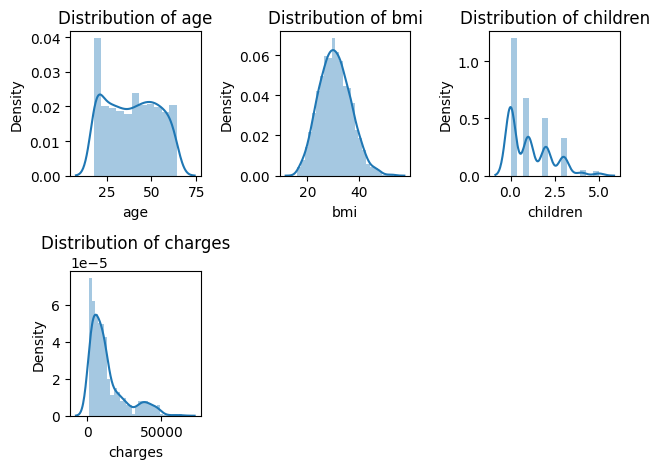

In [14]:
for i , col in enumerate(numerical_col,1):
    plt.subplot(2,3,i)
    sns.distplot(data[col],kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

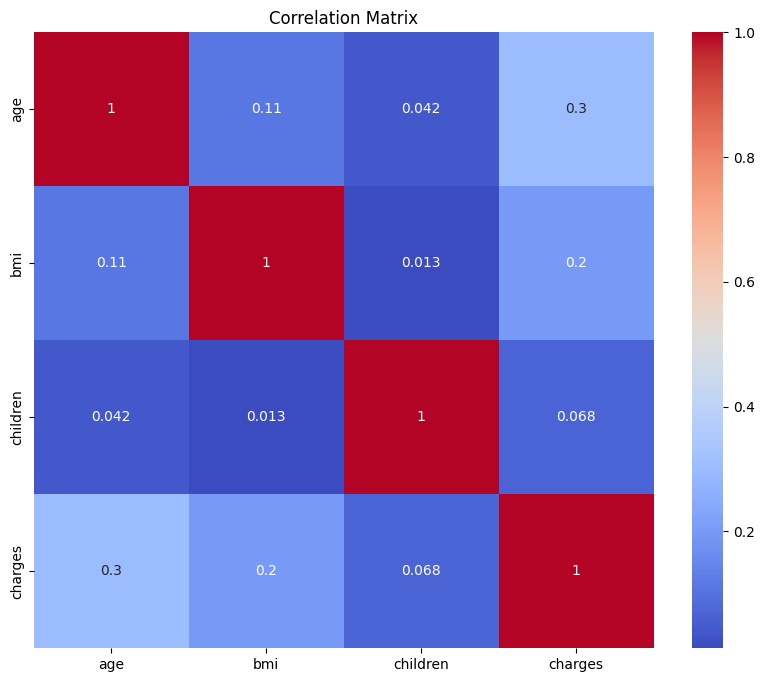

In [18]:
plt.figure(figsize=(10, 8))
numeric_col = data.select_dtypes(include=['number'])
sns.heatmap(numeric_col.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [19]:
data2 = data.copy()

In [20]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    return df

In [23]:
for col in numerical_col:
    if col != 'charges':
        data2 = handle_outliers(data2, col)

In [24]:
data2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [28]:
le = LabelEncoder()
categorical_col = data2.select_dtypes(include=['object']).columns
for col in categorical_col:
    data2[col] = le.fit_transform(data2[col])
data2.describe()

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.650034,1.094918,0.204783,1.515695,13270.422265
std,14.049960,0.500160,6.056926,1.205493,0.403694,1.104885,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515
max,64.000000,1.000000,47.290000,5.000000,1.000000,3.000000,63770.428010


In [27]:
data2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


training the dataset

In [29]:
X = data2.drop('charges', axis=1)
y = data2['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

results = {}
print("Operation 1 Results:")
for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {'MSE': mse, 'R2': r2}

    print(f"\n{name}:")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")


Operation 1 Results:

Linear Regression:
MSE: 33781327.79
R2 Score: 0.78

Decision Tree:
MSE: 47349691.41
R2 Score: 0.70

Random Forest:
MSE: 20929144.16
R2 Score: 0.87

SVR:
MSE: 165839284.26
R2 Score: -0.07

KNN:
MSE: 25675839.20
R2 Score: 0.83


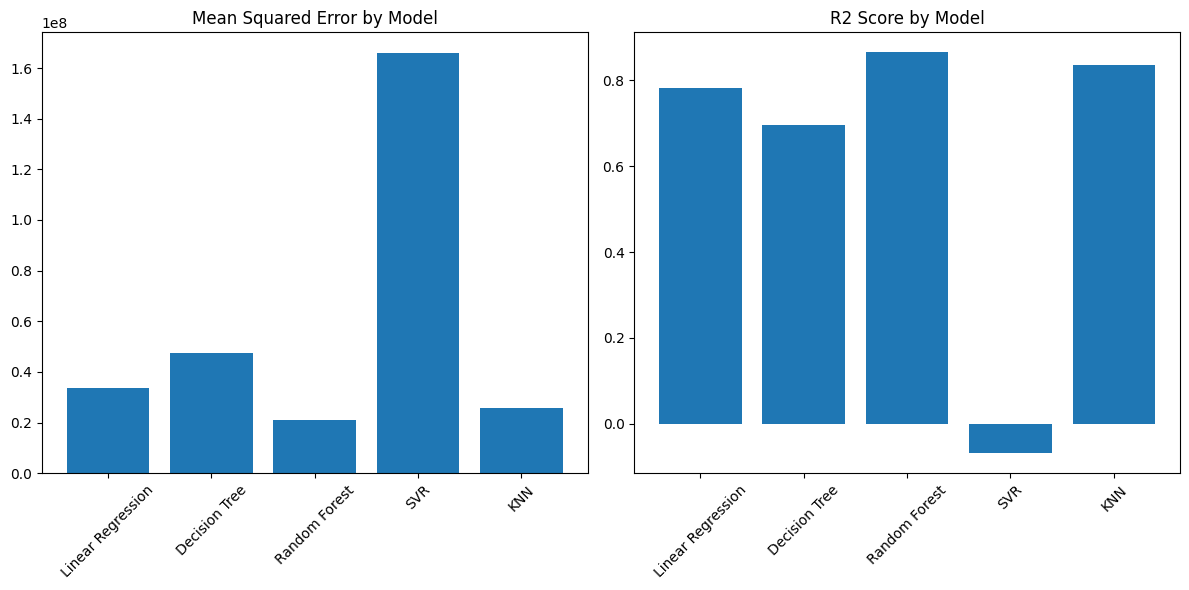

In [33]:
# Cell 9: Visualize model performance
plt.figure(figsize=(12, 6))

# Plot MSE
plt.subplot(1, 2, 1)
plt.bar(results.keys(), [r['MSE'] for r in results.values()])
plt.xticks(rotation=45)
plt.title('Mean Squared Error by Model')

# Plot R2 Score
plt.subplot(1, 2, 2)
plt.bar(results.keys(), [r['R2'] for r in results.values()])
plt.xticks(rotation=45)
plt.title('R2 Score by Model')

plt.tight_layout()
plt.show()


Masking using Bert

In [58]:
from transformers import BertTokenizer, BertForMaskedLM
from transformers import RobertaTokenizer, RobertaForMaskedLM
import torch

In [59]:
data3 = data.copy()

In [70]:
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForMaskedLM.from_pretrained('bert-base-uncased')
bert_model.eval()  # Set to evaluation mode

# Prepare data for BERT
data_bert = data.astype(str)
print("Sample of data prepared for BERT:")
print(data_bert.head())


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Sample of data prepared for BERT:
  age     sex     bmi children smoker     region      charges
0  19  female    27.9        0    yes  southwest    16884.924
1  18    male   33.77        1     no  southeast    1725.5523
2  28    male    33.0        3     no  southeast     4449.462
3  33    male  22.705        0     no  northwest  21984.47061
4  32    male   28.88        0     no  northwest    3866.8552


In [72]:
def predict_with_bert(text, tokenizer, model):
    # Tokenize input
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=-1)

    # Decode predictions
    predicted_tokens = tokenizer.decode(predictions[0])
    return predicted_tokens

In [73]:
data_bert_processed = data_bert.copy()
for column in data_bert_processed.columns:
    if data_bert_processed[column].isnull().any():
        mask = data_bert_processed[column].isnull()

        # Create context for each missing value
        for idx in data_bert_processed[mask].index:
            context = f"The {column} is [MASK]"
            predicted_value = predict_with_bert(context, bert_tokenizer, bert_model)
            data_bert_processed.loc[idx, column] = predicted_value

print("Sample of BERT processed data:")
print(data_bert_processed.head())

Sample of BERT processed data:
  age     sex     bmi children smoker     region      charges
0  19  female    27.9        0    yes  southwest    16884.924
1  18    male   33.77        1     no  southeast    1725.5523
2  28    male    33.0        3     no  southeast     4449.462
3  33    male  22.705        0     no  northwest  21984.47061
4  32    male   28.88        0     no  northwest    3866.8552


In [74]:
roberta_tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
roberta_model = RobertaForMaskedLM.from_pretrained('roberta-base')
roberta_model.eval()  # Set to evaluation mode

# Prepare data for RoBERTa
data_roberta = data.astype(str)
print("Sample of data prepared for RoBERTa:")
print(data_roberta.head())

Sample of data prepared for RoBERTa:
  age     sex     bmi children smoker     region      charges
0  19  female    27.9        0    yes  southwest    16884.924
1  18    male   33.77        1     no  southeast    1725.5523
2  28    male    33.0        3     no  southeast     4449.462
3  33    male  22.705        0     no  northwest  21984.47061
4  32    male   28.88        0     no  northwest    3866.8552


In [75]:
def predict_with_roberta(text, tokenizer, model):
    # Tokenize input
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

    # Get model predictions
    with torch.no_grad():
        outputs = model(**inputs)
        predictions = torch.argmax(outputs.logits, dim=-1)

    # Decode predictions
    predicted_tokens = tokenizer.decode(predictions[0])
    return predicted_tokens

In [76]:
data_roberta_processed = data_roberta.copy()
for column in data_roberta_processed.columns:
    if data_roberta_processed[column].isnull().any():
        mask = data_roberta_processed[column].isnull()

        # Create context for each missing value
        for idx in data_roberta_processed[mask].index:
            context = f"The {column} is <mask>"
            predicted_value = predict_with_roberta(context, roberta_tokenizer, roberta_model)
            data_roberta_processed.loc[idx, column] = predicted_value

print("Sample of RoBERTa processed data:")
print(data_roberta_processed.head())

Sample of RoBERTa processed data:
  age     sex     bmi children smoker     region      charges
0  19  female    27.9        0    yes  southwest    16884.924
1  18    male   33.77        1     no  southeast    1725.5523
2  28    male    33.0        3     no  southeast     4449.462
3  33    male  22.705        0     no  northwest  21984.47061
4  32    male   28.88        0     no  northwest    3866.8552


Prepare BERT processed data for modeling

In [78]:
bert_modeling_data = data_bert_processed.copy()
for column in bert_modeling_data.columns:
    if column in numerical_col:
        bert_modeling_data[column] = pd.to_numeric(bert_modeling_data[column], errors='coerce')

In [79]:
bert_modeling_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
# Convert back to numeric where applicable
bert_modeling_data = data_bert_processed.copy()
for column in bert_modeling_data.columns:
    if column in numerical_col:
        bert_modeling_data[column] = pd.to_numeric(bert_modeling_data[column], errors='coerce')
    # Convert categorical columns back to numeric using Label Encoding if they were originally numeric
    elif column in categorical_col and column != 'charges':  # Exclude target variable
        bert_modeling_data[column] = le.fit_transform(bert_modeling_data[column])  # Use the same LabelEncoder as before

In [81]:
bert_modeling_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [83]:
le = LabelEncoder()
categorical_col = bert_modeling_data.select_dtypes(include=['object']).columns
for col in categorical_col:
    bert_modeling_data[col] = le.fit_transform(data2[col])
bert_modeling_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [84]:
X_bert = bert_modeling_data.drop('charges', axis=1)
y_bert = bert_modeling_data['charges']

X_train_bert, X_test_bert, y_train_bert, y_test_bert = train_test_split(X_bert, y_bert, test_size=0.2, random_state=42)
scaler_bert = StandardScaler()
X_train_bert_scaled = scaler_bert.fit_transform(X_train_bert)
X_test_bert_scaled = scaler_bert.transform(X_test_bert)

In [86]:
roberta_modeling_data = data_roberta_processed.copy()

In [87]:
le = LabelEncoder()
categorical_col = roberta_modeling_data.select_dtypes(include=['object']).columns
for col in categorical_col:
    bert_modeling_data[col] = le.fit_transform(data2[col])
bert_modeling_data.head()

,age,sex,bmi,children,smoker,region,charges
0,1,0,197,0,1,3,1005
1,0,1,350,1,0,2,57
2,10,1,331,3,0,2,306
3,15,1,73,0,0,1,1097
4,14,1,223,0,0,1,254


In [89]:
X_roberta = roberta_modeling_data.drop('charges', axis=1)
y_roberta = roberta_modeling_data['charges']

X_train_roberta, X_test_roberta, y_train_roberta, y_test_roberta = train_test_split(X_roberta, y_roberta, test_size=0.2, random_state=42)
scaler_roberta = StandardScaler()


In [91]:
# Convert categorical columns in roberta_modeling_data to numerical using Label Encoding
for column in roberta_modeling_data.select_dtypes(include=['object']).columns:
    le = LabelEncoder() # Initialize LabelEncoder inside the loop for each column
    roberta_modeling_data[column] = le.fit_transform(roberta_modeling_data[column])

# Now proceed with the rest of your code
X_roberta = roberta_modeling_data.drop('charges', axis=1)
y_roberta = roberta_modeling_data['charges']

X_train_roberta, X_test_roberta, y_train_roberta, y_test_roberta = train_test_split(X_roberta, y_roberta, test_size=0.2, random_state=42)
scaler_roberta = StandardScaler()

X_train_roberta_scaled = scaler_roberta.fit_transform(X_train_roberta)
X_test_roberta_scaled = scaler_roberta.transform(X_test_roberta)

 Evaluate models with BERT processed data

In [92]:
bert_results = {}
print("BERT Processed Data Results:")
for name, model in models.items():
    # Train model
    model.fit(X_train_bert_scaled, y_train_bert)

    # Make predictions
    y_pred = model.predict(X_test_bert_scaled)

    # Calculate metrics
    mse = mean_squared_error(y_test_bert, y_pred)
    r2 = r2_score(y_test_bert, y_pred)

    # Store results
    bert_results[name] = {'MSE': mse, 'R2': r2}

    print(f"\n{name}:")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")


BERT Processed Data Results:

Linear Regression:
MSE: 33635210.43
R2 Score: 0.78

Decision Tree:
MSE: 47349691.41
R2 Score: 0.70

Random Forest:
MSE: 20898625.74
R2 Score: 0.87

SVR:
MSE: 165839509.92
R2 Score: -0.07

KNN:
MSE: 25690352.93
R2 Score: 0.83


Evaluate models with RoBERTa processed data

In [94]:
roberta_results = {}
print("RoBERTa Processed Data Results:")
for name, model in models.items():
    # Train model
    model.fit(X_train_roberta_scaled, y_train_roberta)

    # Make predictions
    y_pred = model.predict(X_test_roberta_scaled)

    # Calculate metrics
    mse = mean_squared_error(y_test_roberta, y_pred)
    r2 = r2_score(y_test_roberta, y_pred)

    # Store results
    roberta_results[name] = {'MSE': mse, 'R2': r2}

    print(f"\n{name}:")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")


RoBERTa Processed Data Results:

Linear Regression:
MSE: 131247.95
R2 Score: 0.03

Decision Tree:
MSE: 58951.18
R2 Score: 0.56

Random Forest:
MSE: 26208.84
R2 Score: 0.81

SVR:
MSE: 129818.55
R2 Score: 0.04

KNN:
MSE: 68575.79
R2 Score: 0.49


Compare results across all approaches

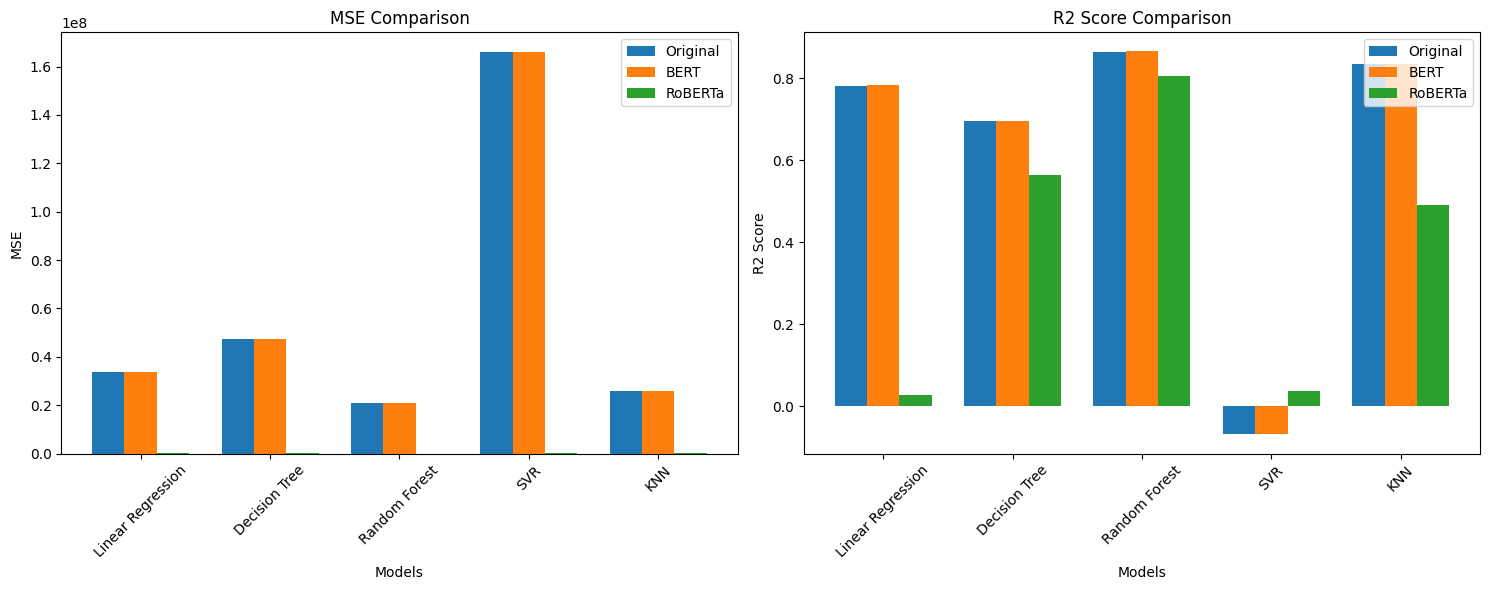

In [95]:
plt.figure(figsize=(15, 6))

# Plot MSE comparison
plt.subplot(1, 2, 1)
x = np.arange(len(models))
width = 0.25

plt.bar(x - width, [results[m]['MSE'] for m in models], width, label='Original')
plt.bar(x, [bert_results[m]['MSE'] for m in models], width, label='BERT')
plt.bar(x + width, [roberta_results[m]['MSE'] for m in models], width, label='RoBERTa')

plt.xlabel('Models')
plt.ylabel('MSE')
plt.title('MSE Comparison')
plt.xticks(x, models.keys(), rotation=45)
plt.legend()

# Plot R2 comparison
plt.subplot(1, 2, 2)
plt.bar(x - width, [results[m]['R2'] for m in models], width, label='Original')
plt.bar(x, [bert_results[m]['R2'] for m in models], width, label='BERT')
plt.bar(x + width, [roberta_results[m]['R2'] for m in models], width, label='RoBERTa')

plt.xlabel('Models')
plt.ylabel('R2 Score')
plt.title('R2 Score Comparison')
plt.xticks(x, models.keys(), rotation=45)
plt.legend()

plt.tight_layout()
plt.show()
